In [2]:
import matplotlib.pyplot as plt
import networkx as nx

In [12]:
graph = {
    "S": {"A": 5, "B": 4},
    "A": {"S": 5, "G": 9},
    "B": {"S": 4, "C": 4, "D": 3},
    "C": {"B": 4, "G": 3},
    "D": {"B": 3},
    "G": {"A": 9, "C": 3},
}

graph

{'S': {'A': 5, 'B': 4},
 'A': {'S': 5, 'G': 9},
 'B': {'S': 4, 'C': 4, 'D': 3},
 'C': {'B': 4, 'G': 3},
 'D': {'B': 3},
 'G': {'A': 9, 'C': 3}}

In [36]:
## create the graph object
G = nx.Graph()

## load edges and weights
for source, neighbors in graph.items():
    for target, weight in neighbors.items():
        G.add_edge(source, target, weight=weight)

## show graph
G.edges(data=True)

EdgeDataView([('S', 'A', {'weight': 5}), ('S', 'B', {'weight': 4}), ('A', 'G', {'weight': 9}), ('B', 'C', {'weight': 4}), ('B', 'D', {'weight': 3}), ('G', 'C', {'weight': 3})])

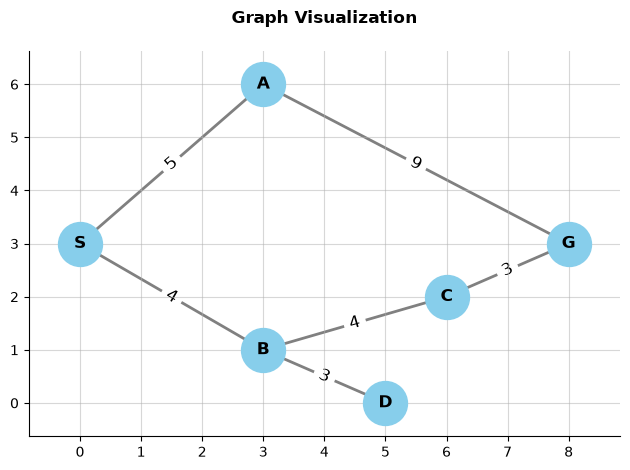

In [83]:
## set coordinates 
coordinates = {
    "S": (0, 3),
    "A": (3, 6),
    "B": (3, 1),
    "D": (5, 0),
    "C": (6, 2),
    "G": (8, 3),
}

## draw nodes, labels, and edges
nx.draw_networkx_nodes(G, coordinates, node_size=1000, node_color="skyblue")
nx.draw_networkx_labels(G, coordinates, font_size=12, font_weight="bold")
nx.draw_networkx_edges(G, coordinates, width=2, edge_color="gray")

## draw edge weights
weights = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, coordinates, edge_labels=weights, font_size=12)

## get current axes
ax = plt.gca()

## add ticks
ax.set_xticks(range(0, 9))
ax.set_yticks(range(0, 7))
ax.grid(True,  alpha=0.5)

## show ticks and numeric labels
ax.tick_params(
    bottom=True,
    left=True,
    labelbottom=True,
    labelleft=True
)

## hide the top and right borders
ax.spines[['top', 'right']].set_visible(False)

## plot graph
plt.title("Graph Visualization", weight="bold", pad=20)
plt.tight_layout()
plt.show()

# Dijkstra

Only considers the actual accumulated cost from the start to node $n$.

$$f(n) = g(n)$$

where:

- $f(n)$: evaluation function; the frontier node with the lowest $f(n)$ is expanded first.
- $g(n)$: actual cost of the path from the start node to $n$.

# Greedy Best-First Search

Only considers the heuristic estimate of the cost from node $n$ to the goal; that is why it is "greedy".

$$f(n) = h(n)$$

where:

- $f(n)$: evaluation function; the frontier node with the lowest $f(n)$ is expanded first.
- $h(n)$: heuristic estimate of the cost from $n$ to the goal.

# A*

Combines both: the actual accumulated cost and the remaining heuristic estimate.

$$f(n) = g(n) + h(n)$$

where:

- $f(n)$: evaluation function; the frontier node with the lowest $f(n)$ is expanded first.
- $g(n)$: actual cost of the path from the start node to $n$.
- $h(n)$: heuristic estimate of the cost from $n$ to the goal.

In [39]:
import heapq
import math

In [41]:
initial_state, goal_state = "S", "G"

In [ ]:
# ## Heuristic: straight-line (Euclidean) distance from n to the goal
# def h(n, goal):
#     distance = math.dist(coordinates[n], coordinates[goal_state])

#     return distance

# h("S")

8.0

In [ ]:
g = {initial_state: 0}
frontier = [(g[initial_state] + h(initial_state), initial_state)]
visited = set()
visit_order = []
parent = {initial_state: None}
 
print("\nEstado inicial:")
print(f"  Nodo de inicio : {initial_state} con g({initial_state}) = 0, "
      f"h({initial_state}) = {h(initial_state):.2f}, f({initial_state}) = {frontier[0][0]:.2f}")
print(f"  Nodo objetivo  : {goal_state}")
print(f"  Frontera (lista abierta / priority queue) : {show(frontier)}")
print(f"  Visitados (lista cerrada)                 : {visited or 'set()'}")
print(f"  Orden de visita                           : {visit_order}")